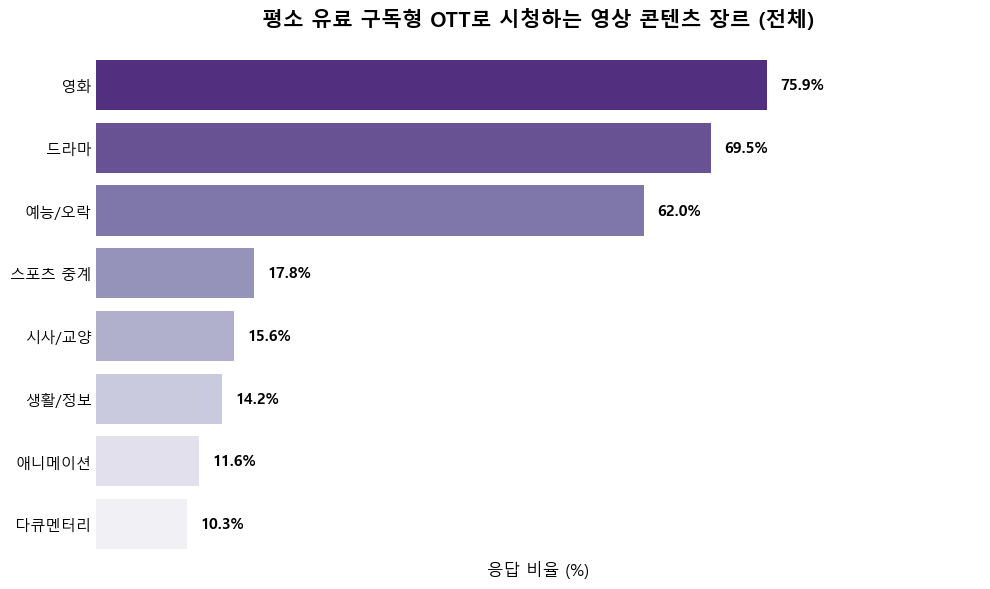

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '평소_유료_구독형_OTT로_시청하는_영상_콘텐츠_장르_복수응답__20260409171620.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '전체' 데이터 추출 및 전처리
# '특성별(1)'이 '전체'인 행만 가져옵니다.
df_total = df[df['특성별(1)'] == '전체'].copy()

# 시각화에 불필요한 컬럼과 '기타 (%)' 항목을 제외합니다.
df_genre = df_total.drop(columns=['특성별(1)', '특성별(2)', '사례수 (명)', '기타 (%)'], errors='ignore')

# 가로로 나열된 데이터를 세로(장르, 비율)로 변환 (Melt)
df_melted = df_genre.melt(var_name='장르', value_name='비율(%)')

# Y축 라벨이 깔끔하게 보이도록 문자열 끝의 ' (%)' 텍스트 제거
df_melted['장르'] = df_melted['장르'].str.replace(r' \(\%\)', '', regex=True).str.replace(' (%)', '', regex=False)

# 응답 비율이 높은 순서대로 내림차순 정렬
df_melted = df_melted.sort_values(by='비율(%)', ascending=False)

# 4. 그래프 그리기 설정
plt.figure(figsize=(10, 6))

# 가로 막대 그래프 생성 (보라색 테마 적용)
ax = sns.barplot(data=df_melted, x='비율(%)', y='장르', hue='장르', palette='Purples_r', legend=False)

# 5. 그래프 디자인 및 꾸미기
# X축 범위를 0~100으로 설정 (복수응답이므로 개별 비율의 최대치는 100%)
ax.set_xlim(0, 100)

# 막대 끝에 수치(텍스트) 표기
for p in ax.patches:
    width = p.get_width()
    if pd.notnull(width) and width > 0:
        # 막대 오른쪽 끝에서 약간(1.5) 떨어진 곳에 텍스트 표시
        ax.text(width + 1.5, 
                p.get_y() + p.get_height() / 2, 
                f'{width:.1f}%', 
                ha='left', 
                va='center', 
                fontsize=11, 
                fontweight='bold')

# 축 및 테두리 정리
plt.title('평소 유료 구독형 OTT로 시청하는 영상 콘텐츠 장르 (전체)', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('응답 비율 (%)', fontsize=12)
plt.ylabel('') # Y축 제목은 항목 자체가 설명하므로 생략

# 위, 오른쪽, 아래 테두리 및 X축 눈금 제거하여 깔끔하게 표시
sns.despine(left=True, bottom=True)
ax.set_xticks([]) 
ax.tick_params(axis='y', length=0, labelsize=11)

plt.tight_layout()
plt.show()

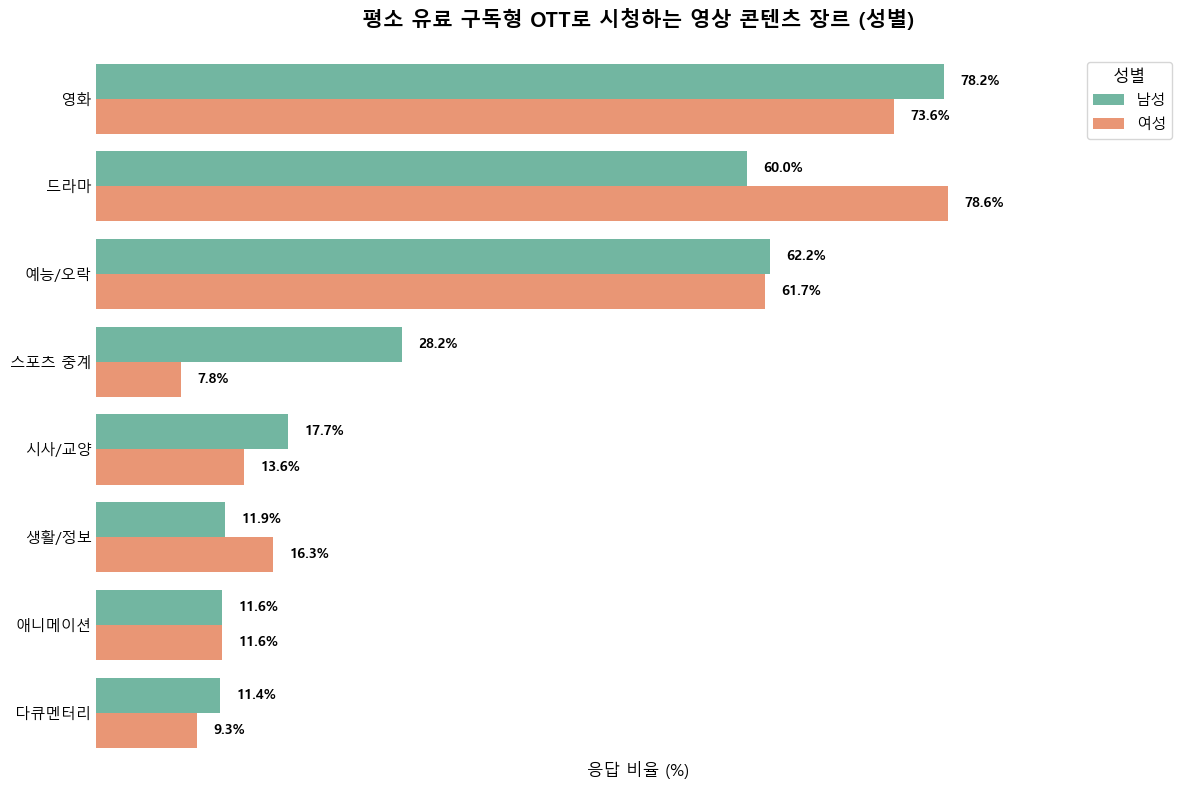

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '평소_유료_구독형_OTT로_시청하는_영상_콘텐츠_장르_복수응답__20260409171620.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '성별' 데이터 추출 및 전처리
# '특성별(1)'이 '성별'인 행만 가져옵니다.
df_gender = df[df['특성별(1)'] == '성별'].copy()

# 시각화에 불필요한 컬럼과 '기타 (%)' 항목을 제외합니다.
df_genre = df_gender.drop(columns=['특성별(1)', '사례수 (명)', '기타 (%)'], errors='ignore')

# 가로로 나열된 데이터를 세로(장르, 비율)로 변환 (Melt)
# '특성별(2)'(성별)를 기준으로 데이터를 변환합니다.
df_melted = df_genre.melt(id_vars='특성별(2)', var_name='장르', value_name='비율(%)')

# 컬럼명 변경
df_melted.rename(columns={'특성별(2)': '성별'}, inplace=True)

# Y축 라벨이 깔끔하게 보이도록 문자열 끝의 ' (%)' 텍스트 제거
df_melted['장르'] = df_melted['장르'].str.replace(r' \(\%\)', '', regex=True).str.replace(' (%)', '', regex=False)

# 4. 그래프 그리기 설정
plt.figure(figsize=(12, 8))

# 막대 그래프 생성 (성별 비교를 위해 x, y축을 변경하고 그룹화)
ax = sns.barplot(data=df_melted, x='비율(%)', y='장르', hue='성별', palette='Set2')

# 5. 그래프 디자인 및 꾸미기
# X축 범위를 0~100으로 설정
ax.set_xlim(0, 100)

# 막대 끝에 수치(텍스트) 표기
for p in ax.patches:
    width = p.get_width()
    if pd.notnull(width) and width > 0:
        # 텍스트 위치 세밀하게 조정
        ax.text(width + 1.5, 
                p.get_y() + p.get_height() / 2, 
                f'{width:.1f}%', 
                ha='left', 
                va='center', 
                fontsize=10, 
                fontweight='bold')

# 축 및 테두리 정리
plt.title('평소 유료 구독형 OTT로 시청하는 영상 콘텐츠 장르 (성별)', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('응답 비율 (%)', fontsize=12)
plt.ylabel('')

# 범례 위치 조정
plt.legend(title='성별', title_fontsize=12, fontsize=11, loc='upper right')

# 위, 오른쪽, 아래 테두리 및 X축 눈금 제거하여 깔끔하게 표시
sns.despine(left=True, bottom=True)
ax.set_xticks([]) 
ax.tick_params(axis='y', length=0, labelsize=11)

plt.tight_layout()
plt.show()

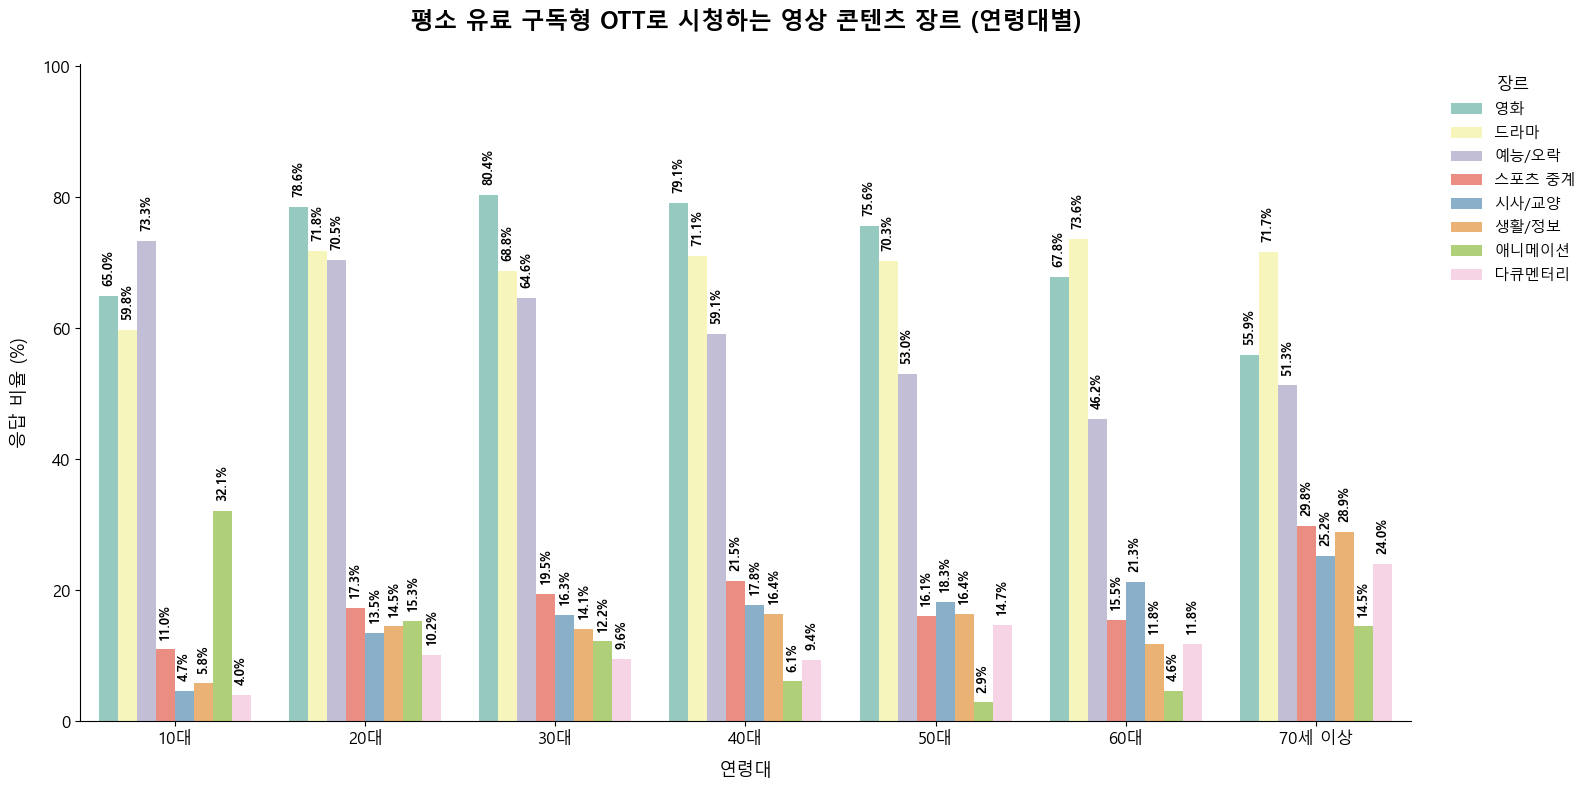

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '평소_유료_구독형_OTT로_시청하는_영상_콘텐츠_장르_복수응답__20260409171620.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '연령' 데이터 추출 및 전처리
# '특성별(1)'이 '연령'인 행만 가져옵니다.
df_age = df[df['특성별(1)'] == '연령'].copy()

# 시각화에 불필요한 컬럼과 '기타 (%)' 항목을 제외합니다.
df_genre = df_age.drop(columns=['특성별(1)', '사례수 (명)', '기타 (%)'], errors='ignore')

# 가로로 나열된 데이터를 세로(장르, 비율)로 변환 (Melt)
# '특성별(2)'(연령대)를 기준으로 데이터를 변환합니다.
df_melted = df_genre.melt(id_vars='특성별(2)', var_name='장르', value_name='비율(%)')

# 컬럼명 변경
df_melted.rename(columns={'특성별(2)': '연령대'}, inplace=True)

# Y축 라벨이 깔끔하게 보이도록 문자열 끝의 ' (%)' 텍스트 제거
df_melted['장르'] = df_melted['장르'].str.replace(r' \(\%\)', '', regex=True).str.replace(' (%)', '', regex=False)

# 4. 그래프 그리기 설정
# 항목이 많으므로 그래프 크기를 넓게 설정합니다.
plt.figure(figsize=(16, 8))

# 막대 그래프 생성 (X축: 연령대, 색상 구분: 장르)
ax = sns.barplot(data=df_melted, x='연령대', y='비율(%)', hue='장르', palette='Set3')

# 5. 그래프 디자인 및 꾸미기
# 범례와 텍스트를 위해 Y축 범위를 더 넉넉하게 설정
max_val = df_melted['비율(%)'].max()
ax.set_ylim(0, max_val + 20)

# 막대 위에 수치(텍스트) 표기
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        # 막대가 좁으므로 텍스트가 겹치지 않게 세로(90도)로 회전시킵니다.
        ax.text(p.get_x() + p.get_width() / 2., 
                height + 1.5, 
                f'{height:.1f}%', 
                ha='center', 
                va='bottom', 
                fontsize=9, 
                fontweight='bold',
                rotation=90) 

# 축 및 테두리 정리
plt.title('평소 유료 구독형 OTT로 시청하는 영상 콘텐츠 장르 (연령대별)', fontsize=17, pad=25, fontweight='bold')
plt.xlabel('연령대', fontsize=13, labelpad=10)
plt.ylabel('응답 비율 (%)', fontsize=13, labelpad=10)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 범례 위치 조정 (그래프 우측 바깥으로 분리)
plt.legend(title='장르', title_fontsize=12, fontsize=11, loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False)

# 위, 오른쪽 테두리 제거하여 깔끔하게 표시
sns.despine()

plt.tight_layout()
plt.show()

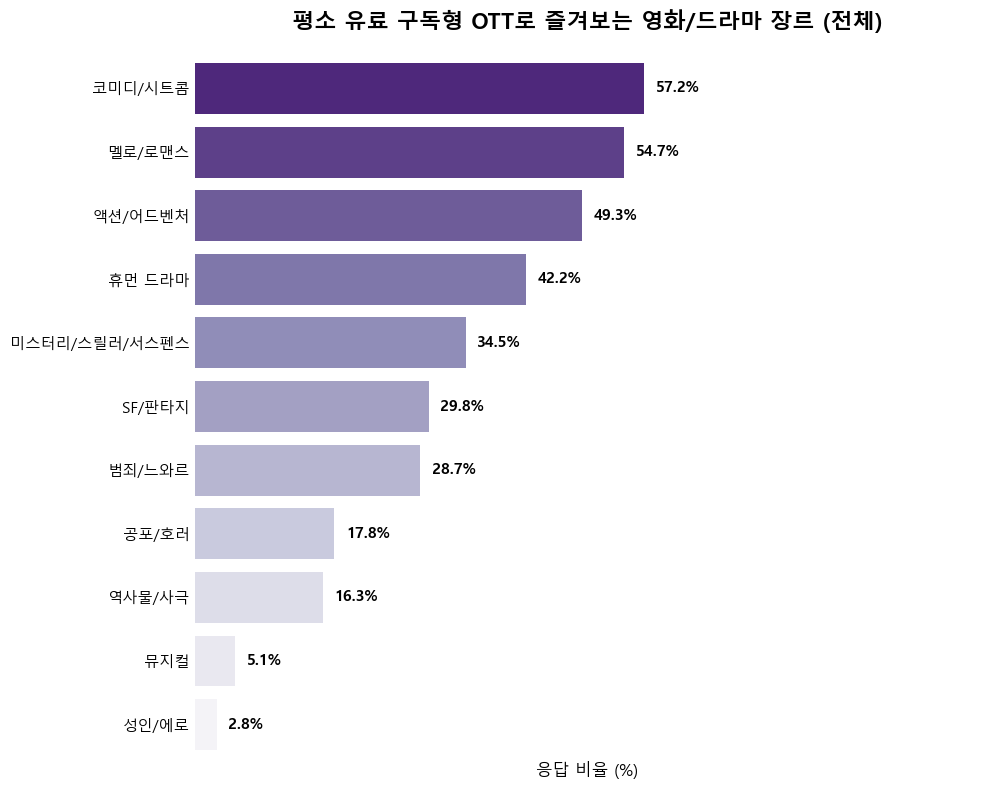

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '평소_유료_구독형_OTT로_즐겨보는_영화_드라마_장르_복수응답__20260409172526.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '전체' 데이터 추출 및 전처리
# '특성별(1)'이 '전체'인 행만 가져옵니다.
df_total = df[df['특성별(1)'] == '전체'].copy()

# 시각화에 불필요한 컬럼을 제외합니다.
df_genre = df_total.drop(columns=['특성별(1)', '특성별(2)', '사례수 (명)'], errors='ignore')

# 가로로 나열된 데이터를 세로(장르, 비율)로 변환 (Melt)
df_melted = df_genre.melt(var_name='장르', value_name='비율(%)')

# Y축 라벨이 깔끔하게 보이도록 문자열 끝의 ' (%)' 텍스트 제거
df_melted['장르'] = df_melted['장르'].str.replace(r' \(\%\)', '', regex=True).str.replace(' (%)', '', regex=False)

# 응답 비율이 높은 순서대로 내림차순 정렬
df_melted = df_melted.sort_values(by='비율(%)', ascending=False)

# 4. 그래프 그리기 설정
# 항목 텍스트가 길고 많으므로 세로 길이를 충분히 줍니다.
plt.figure(figsize=(10, 8))

# 가로 막대 그래프 생성 (색상은 비율이 높을수록 진하게 표현되는 'Purples_r' 테마 적용)
ax = sns.barplot(data=df_melted, x='비율(%)', y='장르', hue='장르', palette='Purples_r', legend=False)

# 5. 그래프 디자인 및 꾸미기
# X축 범위를 0~100으로 설정 (복수응답이므로 개별 비율의 최대치는 100%)
ax.set_xlim(0, 100)

# 막대 끝에 수치(텍스트) 표기
for p in ax.patches:
    width = p.get_width()
    if pd.notnull(width) and width > 0:
        # 막대 오른쪽 끝에서 약간(1.5) 떨어진 곳에 텍스트 표시
        ax.text(width + 1.5, 
                p.get_y() + p.get_height() / 2, 
                f'{width:.1f}%', 
                ha='left', 
                va='center', 
                fontsize=11, 
                fontweight='bold')

# 축 및 테두리 정리
plt.title('평소 유료 구독형 OTT로 즐겨보는 영화/드라마 장르 (전체)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('응답 비율 (%)', fontsize=12)
plt.ylabel('') # Y축 제목은 항목 자체가 설명하므로 생략

# 위, 오른쪽, 아래 테두리 및 X축 눈금 제거하여 깔끔하게 표시
sns.despine(left=True, bottom=True)
ax.set_xticks([]) 
ax.tick_params(axis='y', length=0, labelsize=11)

plt.tight_layout()
plt.show()

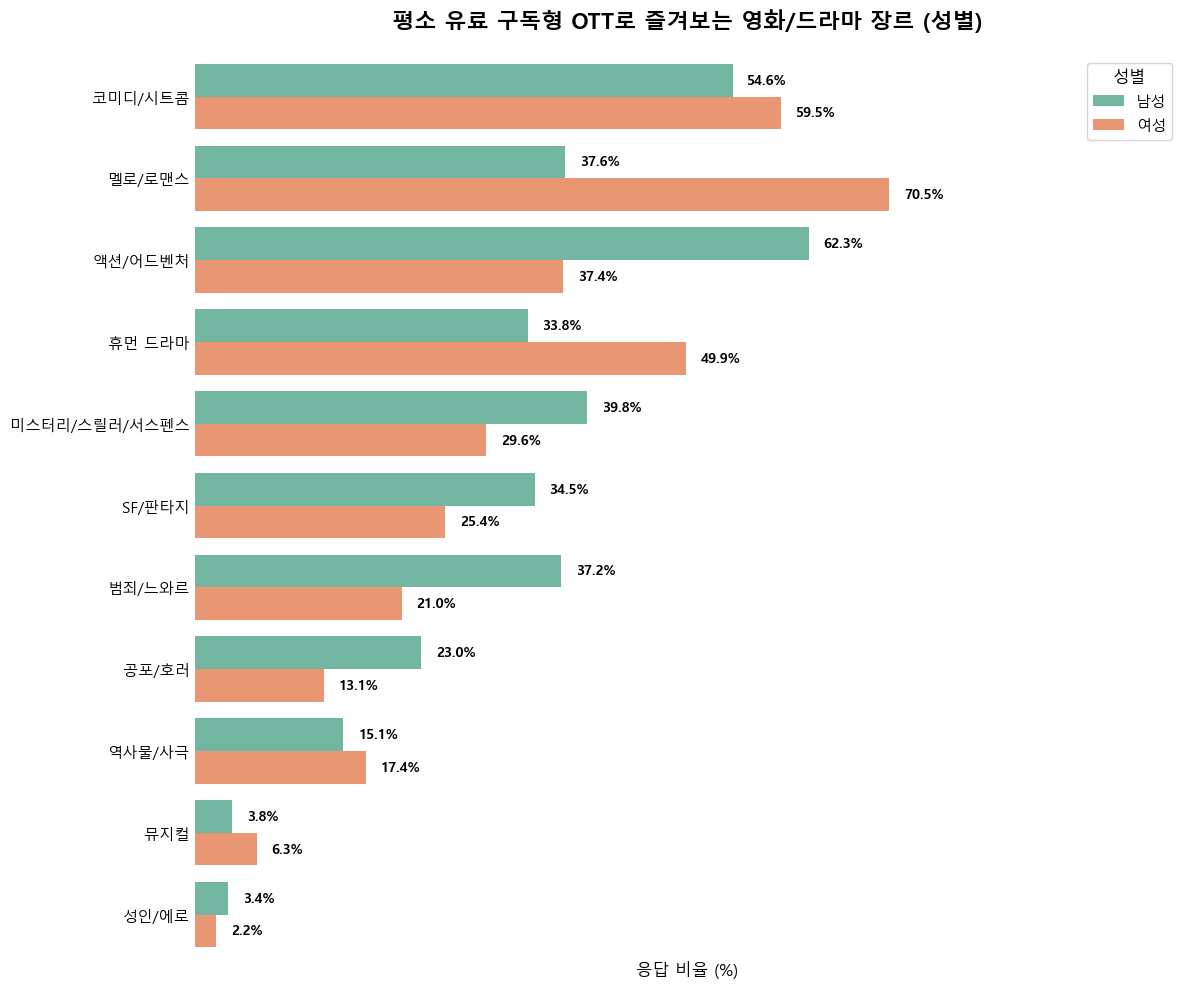

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '평소_유료_구독형_OTT로_즐겨보는_영화_드라마_장르_복수응답__20260409172526.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '성별' 데이터 추출 및 전처리
# '특성별(1)'이 '성별'인 행만 가져옵니다.
df_gender = df[df['특성별(1)'] == '성별'].copy()

# 시각화에 불필요한 컬럼을 제외합니다.
df_genre = df_gender.drop(columns=['특성별(1)', '사례수 (명)'], errors='ignore')

# 가로로 나열된 데이터를 세로(장르, 비율)로 변환 (Melt)
# '특성별(2)'(성별)를 기준으로 데이터를 변환합니다.
df_melted = df_genre.melt(id_vars='특성별(2)', var_name='장르', value_name='비율(%)')

# 컬럼명 변경
df_melted.rename(columns={'특성별(2)': '성별'}, inplace=True)

# Y축 라벨이 깔끔하게 보이도록 문자열 끝의 ' (%)' 텍스트 제거
df_melted['장르'] = df_melted['장르'].str.replace(r' \(\%\)', '', regex=True).str.replace(' (%)', '', regex=False)

# 4. 그래프 그리기 설정
# 항목 텍스트가 길고 남녀 두 개의 막대가 들어가므로 세로 길이를 충분히 줍니다.
plt.figure(figsize=(12, 10))

# 가로 막대 그래프 생성 (성별 비교를 위해 hue 추가, 색상 테마 변경)
ax = sns.barplot(data=df_melted, x='비율(%)', y='장르', hue='성별', palette='Set2')

# 5. 그래프 디자인 및 꾸미기
# X축 범위를 0~100으로 설정 (복수응답이므로 개별 비율의 최대치는 100%)
ax.set_xlim(0, 100)

# 막대 끝에 수치(텍스트) 표기
for p in ax.patches:
    width = p.get_width()
    if pd.notnull(width) and width > 0:
        # 막대 오른쪽 끝에서 약간(1.5) 떨어진 곳에 텍스트 표시
        ax.text(width + 1.5, 
                p.get_y() + p.get_height() / 2, 
                f'{width:.1f}%', 
                ha='left', 
                va='center', 
                fontsize=10, 
                fontweight='bold')

# 축 및 테두리 정리
plt.title('평소 유료 구독형 OTT로 즐겨보는 영화/드라마 장르 (성별)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('응답 비율 (%)', fontsize=12)
plt.ylabel('') # Y축 제목은 항목 자체가 설명하므로 생략

# 범례 위치 조정
plt.legend(title='성별', title_fontsize=12, fontsize=11, loc='upper right')

# 위, 오른쪽, 아래 테두리 및 X축 눈금 제거하여 깔끔하게 표시
sns.despine(left=True, bottom=True)
ax.set_xticks([]) 
ax.tick_params(axis='y', length=0, labelsize=11)

plt.tight_layout()
plt.show()

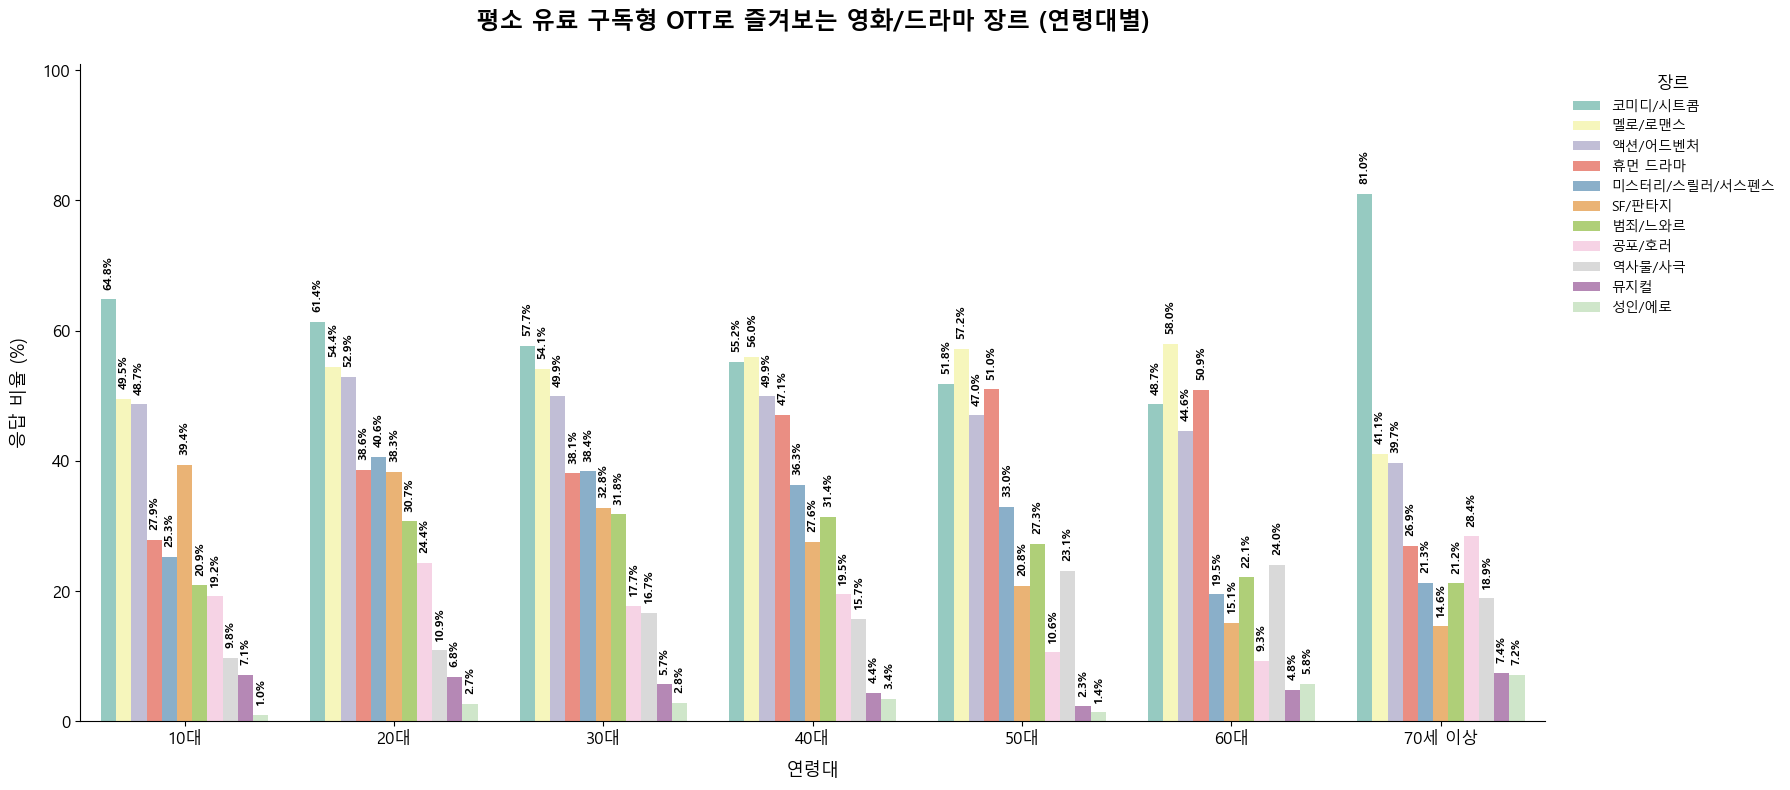

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '평소_유료_구독형_OTT로_즐겨보는_영화_드라마_장르_복수응답__20260409172526.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '연령' 데이터 추출 및 전처리
# '특성별(1)'이 '연령'인 행만 가져옵니다.
df_age = df[df['특성별(1)'] == '연령'].copy()

# 시각화에 불필요한 컬럼을 제외합니다.
df_genre = df_age.drop(columns=['특성별(1)', '사례수 (명)'], errors='ignore')

# 가로로 나열된 데이터를 세로(장르, 비율)로 변환 (Melt)
# '특성별(2)'(연령대)를 기준으로 데이터를 변환합니다.
df_melted = df_genre.melt(id_vars='특성별(2)', var_name='장르', value_name='비율(%)')

# 컬럼명 변경
df_melted.rename(columns={'특성별(2)': '연령대'}, inplace=True)

# Y축 라벨이 깔끔하게 보이도록 문자열 끝의 ' (%)' 텍스트 제거
df_melted['장르'] = df_melted['장르'].str.replace(r' \(\%\)', '', regex=True).str.replace(' (%)', '', regex=False)

# 4. 그래프 그리기 설정
# 항목이 많으므로 그래프 크기를 가로로 아주 넓게 설정합니다.
plt.figure(figsize=(18, 8))

# 세로 막대 그래프 생성 (X축: 연령대, 색상 구분: 장르)
ax = sns.barplot(data=df_melted, x='연령대', y='비율(%)', hue='장르', palette='Set3')

# 5. 그래프 디자인 및 꾸미기
# 범례와 텍스트를 위해 Y축 범위를 더 넉넉하게 설정
max_val = df_melted['비율(%)'].max()
ax.set_ylim(0, max_val + 20)

# 막대 위에 수치(텍스트) 표기
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        # 막대가 좁으므로 텍스트가 겹치지 않게 세로(90도)로 회전시킵니다.
        ax.text(p.get_x() + p.get_width() / 2., 
                height + 1.5, 
                f'{height:.1f}%', 
                ha='center', 
                va='bottom', 
                fontsize=8.5, 
                fontweight='bold',
                rotation=90) 

# 축 및 테두리 정리
plt.title('평소 유료 구독형 OTT로 즐겨보는 영화/드라마 장르 (연령대별)', fontsize=17, pad=25, fontweight='bold')
plt.xlabel('연령대', fontsize=13, labelpad=10)
plt.ylabel('응답 비율 (%)', fontsize=13, labelpad=10)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 범례 위치 조정 (그래프 우측 바깥으로 분리)
plt.legend(title='장르', title_fontsize=12, fontsize=10, loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False)

# 위, 오른쪽 테두리 제거하여 깔끔하게 표시
sns.despine()

plt.tight_layout()
plt.show()

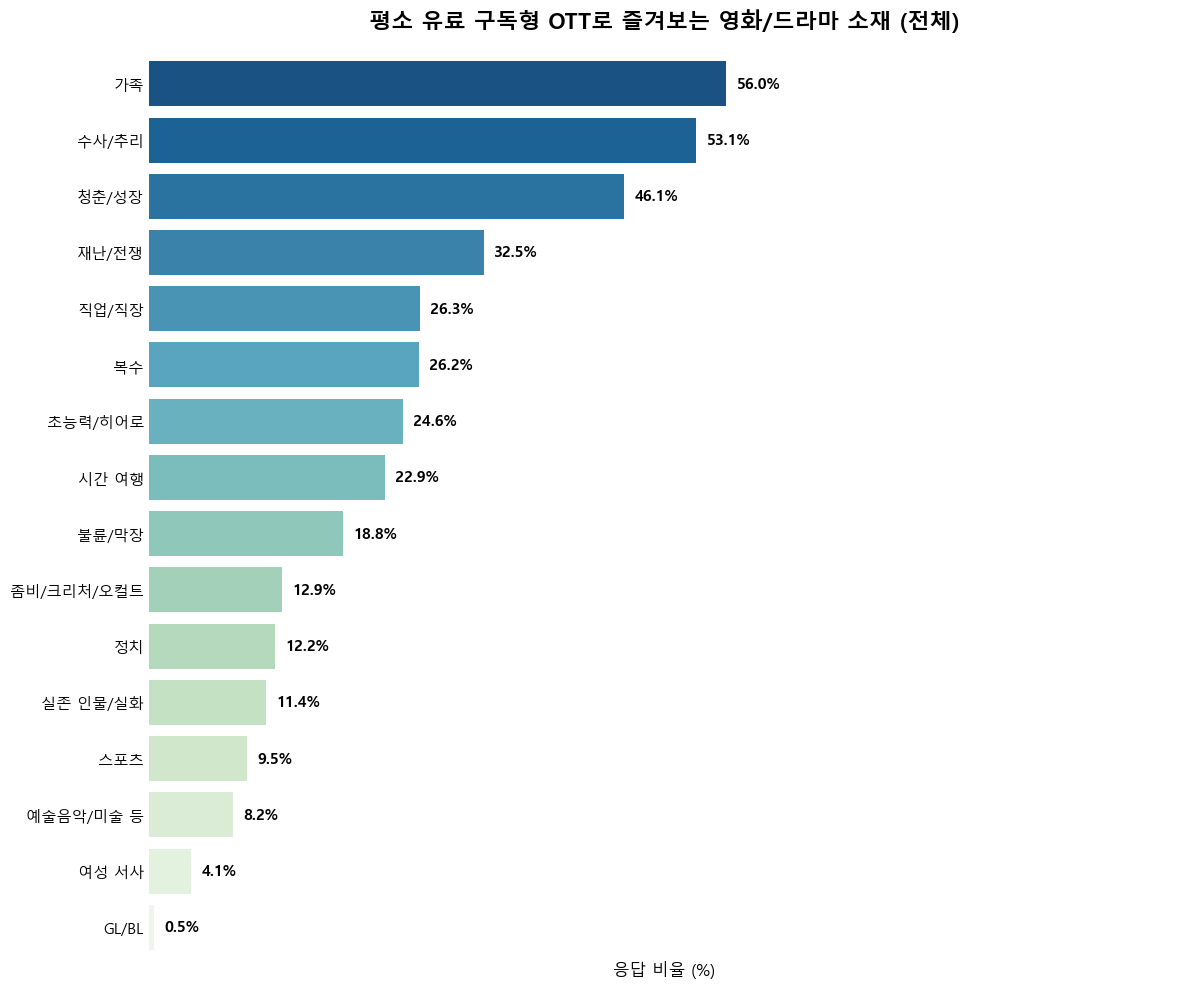

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '평소_유료_구독형_OTT로_즐겨보는_영화_드라마_소재_복수응답__20260409173746.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '전체' 데이터 추출 및 전처리
# '특성별(1)'이 '전체'인 행만 가져옵니다.
df_total = df[df['특성별(1)'] == '전체'].copy()

# 시각화에 불필요한 컬럼을 제외합니다.
df_subject = df_total.drop(columns=['특성별(1)', '특성별(2)', '사례수 (명)'], errors='ignore')

# 가로로 나열된 데이터를 세로(소재, 비율)로 변환 (Melt)
df_melted = df_subject.melt(var_name='소재', value_name='비율(%)')

# Y축 라벨이 깔끔하게 보이도록 문자열 끝의 ' (%)' 텍스트 제거
df_melted['소재'] = df_melted['소재'].str.replace(r' \(\%\)', '', regex=True).str.replace(' (%)', '', regex=False)

# 응답 비율이 높은 순서대로 내림차순 정렬
df_melted = df_melted.sort_values(by='비율(%)', ascending=False)

# 4. 그래프 그리기 설정
# 항목 텍스트가 길고 많으므로 세로 길이를 충분히 줍니다.
plt.figure(figsize=(12, 10))

# 가로 막대 그래프 생성 (색상은 비율이 높을수록 진하게 표현되는 'GnBu_r' 테마 적용)
ax = sns.barplot(data=df_melted, x='비율(%)', y='소재', hue='소재', palette='GnBu_r', legend=False)

# 5. 그래프 디자인 및 꾸미기
# X축 범위를 0~100으로 설정 (복수응답이므로 개별 비율의 최대치는 100%)
ax.set_xlim(0, 100)

# 막대 끝에 수치(텍스트) 표기
for p in ax.patches:
    width = p.get_width()
    if pd.notnull(width) and width > 0:
        # 막대 오른쪽 끝에서 약간 떨어진 곳에 텍스트 표시
        ax.text(width + 1.0, 
                p.get_y() + p.get_height() / 2, 
                f'{width:.1f}%', 
                ha='left', 
                va='center', 
                fontsize=11, 
                fontweight='bold')

# 축 및 테두리 정리
plt.title('평소 유료 구독형 OTT로 즐겨보는 영화/드라마 소재 (전체)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('응답 비율 (%)', fontsize=12)
plt.ylabel('') # Y축 제목은 항목 자체가 설명하므로 생략

# 위, 오른쪽, 아래 테두리 및 X축 눈금 제거하여 깔끔하게 표시
sns.despine(left=True, bottom=True)
ax.set_xticks([]) 
ax.tick_params(axis='y', length=0, labelsize=11)

plt.tight_layout()
plt.show()

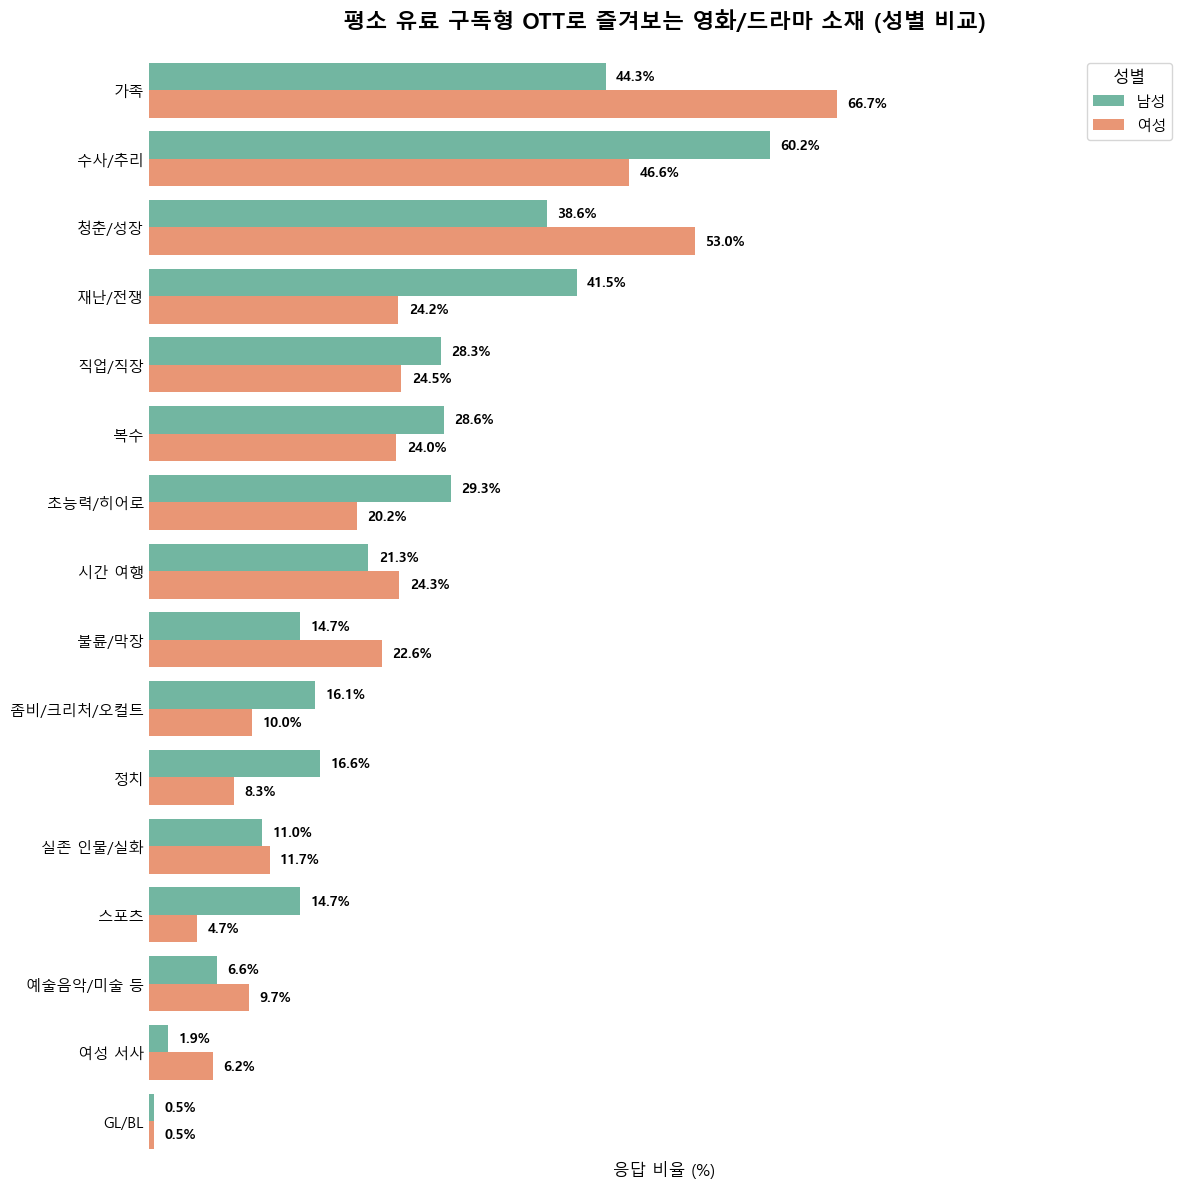

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '평소_유료_구독형_OTT로_즐겨보는_영화_드라마_소재_복수응답__20260409173746.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '성별' 데이터 추출 및 전처리
# '특성별(1)'이 '성별'인 행만 가져옵니다.
df_gender = df[df['특성별(1)'] == '성별'].copy()

# 시각화에 불필요한 컬럼을 제외합니다. ('특성별(2)'는 성별 구분을 위해 남겨둡니다)
df_subject = df_gender.drop(columns=['특성별(1)', '사례수 (명)'], errors='ignore')

# 가로로 나열된 데이터를 세로(소재, 비율)로 변환 (Melt)
# '특성별(2)'(성별)를 기준으로 데이터를 변환합니다.
df_melted = df_subject.melt(id_vars='특성별(2)', var_name='소재', value_name='비율(%)')

# 컬럼명 변경
df_melted.rename(columns={'특성별(2)': '성별'}, inplace=True)

# Y축 라벨이 깔끔하게 보이도록 문자열 끝의 ' (%)' 텍스트 제거
df_melted['소재'] = df_melted['소재'].str.replace(r' \(\%\)', '', regex=True).str.replace(' (%)', '', regex=False)

# 4. 그래프 그리기 설정
# 항목 텍스트가 길고 남녀 막대가 각각 들어가므로 세로 길이를 넉넉하게 줍니다.
plt.figure(figsize=(12, 12))

# 가로 막대 그래프 생성 (성별 비교를 위해 hue를 추가하고, 구분하기 쉬운 Set2 테마 적용)
ax = sns.barplot(data=df_melted, x='비율(%)', y='소재', hue='성별', palette='Set2')

# 5. 그래프 디자인 및 꾸미기
# X축 범위를 0~100으로 설정 (복수응답이므로 개별 비율의 최대치는 100%)
ax.set_xlim(0, 100)

# 막대 끝에 수치(텍스트) 표기
for p in ax.patches:
    width = p.get_width()
    if pd.notnull(width) and width > 0:
        # 막대 오른쪽 끝에서 약간 떨어진 곳에 텍스트 표시
        ax.text(width + 1.0, 
                p.get_y() + p.get_height() / 2, 
                f'{width:.1f}%', 
                ha='left', 
                va='center', 
                fontsize=10, 
                fontweight='bold')

# 축 및 테두리 정리
plt.title('평소 유료 구독형 OTT로 즐겨보는 영화/드라마 소재 (성별 비교)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('응답 비율 (%)', fontsize=12)
plt.ylabel('') # Y축 제목은 항목 자체가 설명하므로 생략

# 범례 위치 조정
plt.legend(title='성별', title_fontsize=12, fontsize=11, loc='upper right')

# 위, 오른쪽, 아래 테두리 및 X축 눈금 제거하여 깔끔하게 표시
sns.despine(left=True, bottom=True)
ax.set_xticks([]) 
ax.tick_params(axis='y', length=0, labelsize=11)

plt.tight_layout()
plt.show()

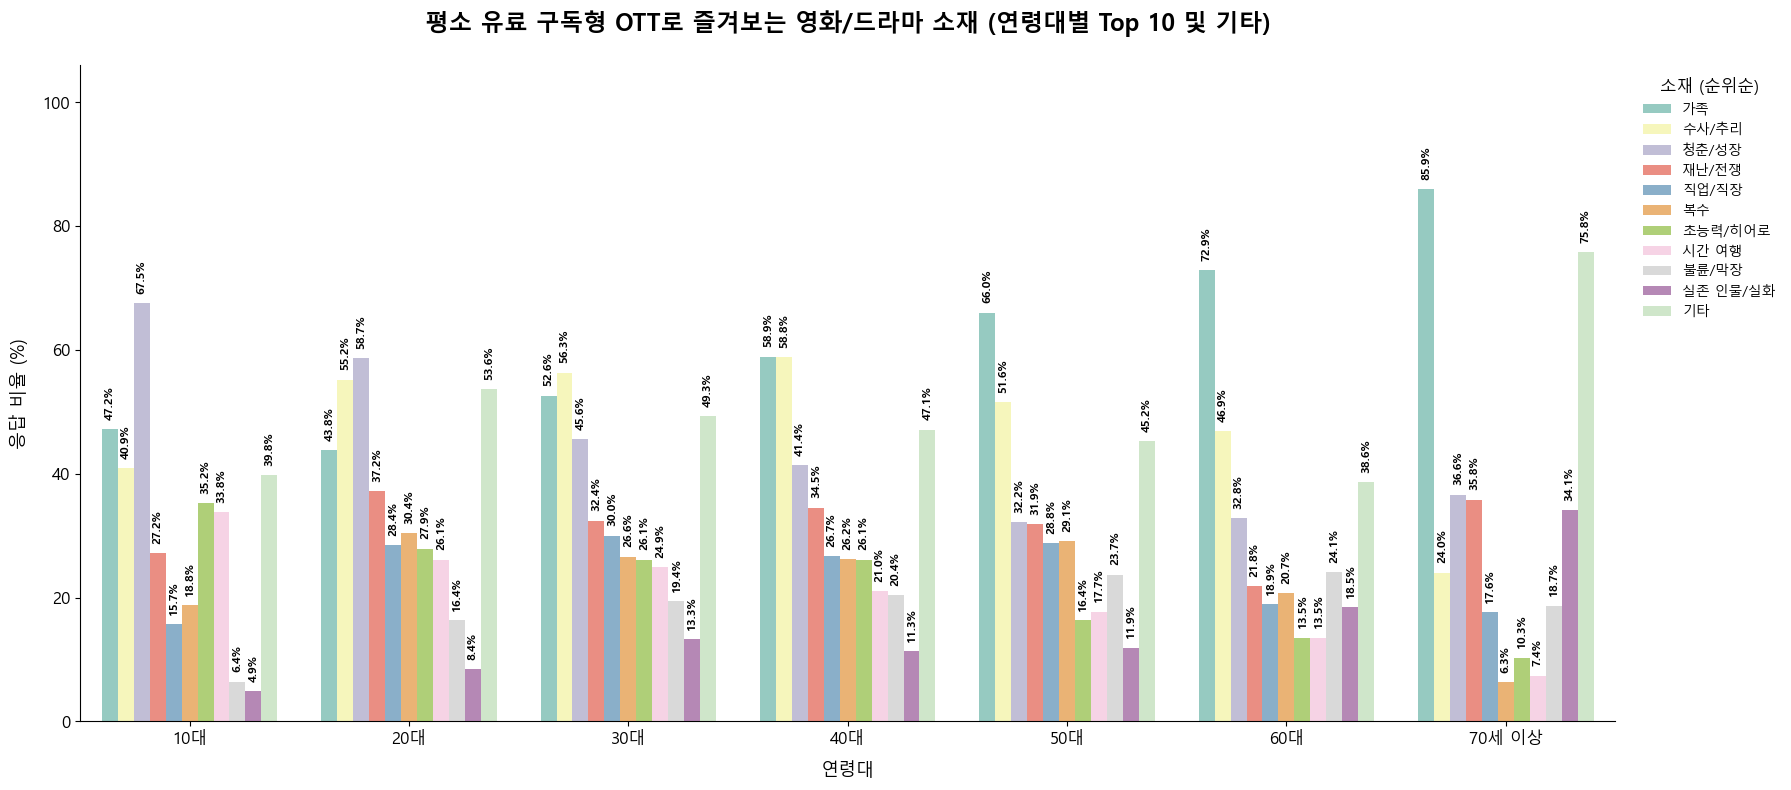

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '평소_유료_구독형_OTT로_즐겨보는_영화_드라마_소재_복수응답__20260409173746.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '연령' 데이터 추출 및 전처리
# '특성별(1)'이 '연령'인 행만 가져옵니다.
df_age = df[df['특성별(1)'] == '연령'].copy()

# 소재 항목 컬럼만 추출
subject_cols = [col for col in df_age.columns if col not in ['특성별(1)', '특성별(2)', '사례수 (명)']]

# 각 소재별 평균을 계산하여 선호도가 높은 상위 10개 항목 추출
top10_subjects = df_age[subject_cols].mean().sort_values(ascending=False).head(10).index.tolist()

# 상위 10개에 포함되지 않는 나머지 하위 항목들
other_subjects = [col for col in subject_cols if col not in top10_subjects]

# 하위 항목들의 응답 비율을 합산하여 '기타 (%)' 파생 변수 생성
df_age['기타 (%)'] = df_age[other_subjects].sum(axis=1)

# 분석에 사용할 컬럼 (연령대 + 상위 10개 + 기타)만 필터링
cols_to_keep = ['특성별(2)'] + top10_subjects + ['기타 (%)']
df_plot = df_age[cols_to_keep].copy()

# 가로로 나열된 데이터를 세로(소재, 비율)로 변환 (Melt)
df_melted = df_plot.melt(id_vars='특성별(2)', var_name='소재', value_name='비율(%)')

# 컬럼명 변경
df_melted.rename(columns={'특성별(2)': '연령대'}, inplace=True)

# Y축 라벨이 깔끔하게 보이도록 문자열 끝의 ' (%)' 텍스트 제거
df_melted['소재'] = df_melted['소재'].str.replace(r' \(\%\)', '', regex=True).str.replace(' (%)', '', regex=False)

# 4. 그래프 그리기 설정
# 연령대별로 11개의 막대가 들어가므로 가로 길이를 아주 넓게 설정합니다.
plt.figure(figsize=(18, 8))

# 세로 막대 그래프 생성 (X축: 연령대, 색상 구분: 소재, 11개 색상이 있는 Set3 테마 적용)
ax = sns.barplot(data=df_melted, x='연령대', y='비율(%)', hue='소재', palette='Set3')

# 5. 그래프 디자인 및 꾸미기
# 텍스트와 범례 공간 확보를 위해 Y축 범위를 넉넉하게 설정
max_val = df_melted['비율(%)'].max()
ax.set_ylim(0, max_val + 20)

# 막대 위에 수치(텍스트) 표기
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        # 막대가 좁으므로 텍스트가 겹치지 않게 세로(90도)로 회전시킵니다.
        ax.text(p.get_x() + p.get_width() / 2., 
                height + 1.5, 
                f'{height:.1f}%', 
                ha='center', 
                va='bottom', 
                fontsize=8.5, 
                fontweight='bold',
                rotation=90)

# 축 및 테두리 정리
plt.title('평소 유료 구독형 OTT로 즐겨보는 영화/드라마 소재 (연령대별 Top 10 및 기타)', fontsize=17, pad=25, fontweight='bold')
plt.xlabel('연령대', fontsize=13, labelpad=10)
plt.ylabel('응답 비율 (%)', fontsize=13, labelpad=10)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 범례 위치 조정 (그래프 우측 바깥으로 분리)
plt.legend(title='소재 (순위순)', title_fontsize=12, fontsize=10, loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False)

# 위, 오른쪽 테두리 제거하여 깔끔하게 표시
sns.despine()

plt.tight_layout()
plt.show()

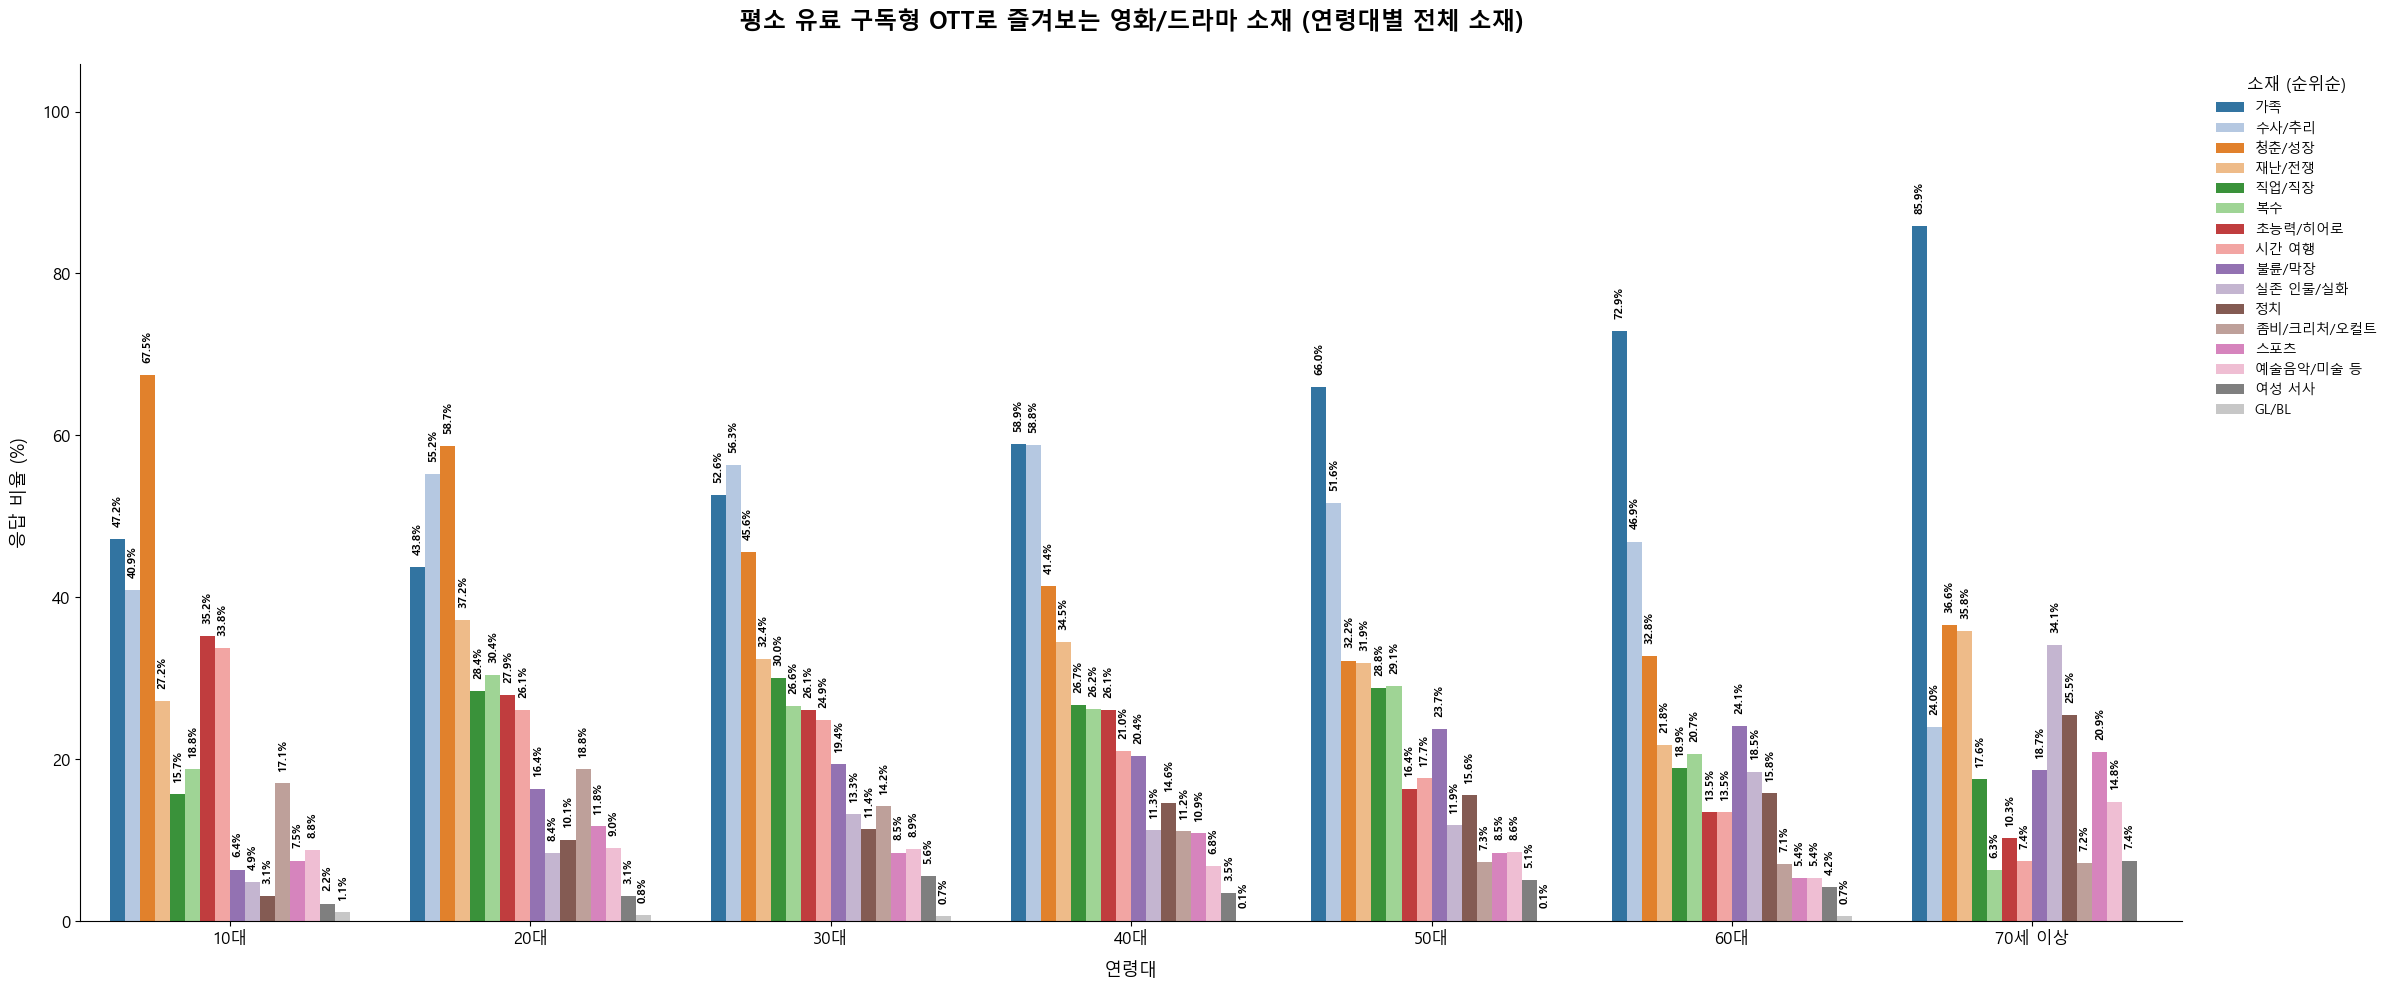

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '평소_유료_구독형_OTT로_즐겨보는_영화_드라마_소재_복수응답__20260409173746.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '연령' 데이터 추출 및 전처리
# '특성별(1)'이 '연령'인 행만 가져옵니다.
df_age = df[df['특성별(1)'] == '연령'].copy()

# 소재 항목 컬럼만 추출
subject_cols = [col for col in df_age.columns if col not in ['특성별(1)', '특성별(2)', '사례수 (명)']]

# 기타로 묶지 않고 전체 소재를 그대로 사용하되, 보기 좋게 전체 평균 선호도 순으로 정렬합니다.
sorted_subjects = df_age[subject_cols].mean().sort_values(ascending=False).index.tolist()

# 분석에 사용할 컬럼 (연령대 + 정렬된 모든 소재) 필터링
cols_to_keep = ['특성별(2)'] + sorted_subjects
df_plot = df_age[cols_to_keep].copy()

# 가로로 나열된 데이터를 세로(소재, 비율)로 변환 (Melt)
df_melted = df_plot.melt(id_vars='특성별(2)', var_name='소재', value_name='비율(%)')

# 컬럼명 변경
df_melted.rename(columns={'특성별(2)': '연령대'}, inplace=True)

# Y축 라벨이 깔끔하게 보이도록 문자열 끝의 ' (%)' 텍스트 제거
df_melted['소재'] = df_melted['소재'].str.replace(r' \(\%\)', '', regex=True).str.replace(' (%)', '', regex=False)

# 4. 그래프 그리기 설정
# 16개의 모든 소재 막대가 들어가므로 가로 길이를 더 넓게(24) 설정합니다.
plt.figure(figsize=(24, 10))

# 세로 막대 그래프 생성 
# (16개 항목이므로 색상 구분이 잘 되도록 최대 20가지를 지원하는 'tab20' 팔레트 적용)
ax = sns.barplot(data=df_melted, x='연령대', y='비율(%)', hue='소재', palette='tab20')

# 5. 그래프 디자인 및 꾸미기
# 텍스트와 범례 공간 확보를 위해 Y축 범위를 넉넉하게 설정
max_val = df_melted['비율(%)'].max()
ax.set_ylim(0, max_val + 20)

# 막대 위에 수치(텍스트) 표기
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        # 막대가 좁으므로 텍스트가 겹치지 않게 세로(90도)로 회전시킵니다.
        ax.text(p.get_x() + p.get_width() / 2., 
                height + 1.5, 
                f'{height:.1f}%', 
                ha='center', 
                va='bottom', 
                fontsize=8, 
                fontweight='bold',
                rotation=90)

# 축 및 테두리 정리
plt.title('평소 유료 구독형 OTT로 즐겨보는 영화/드라마 소재 (연령대별 전체 소재)', fontsize=17, pad=25, fontweight='bold')
plt.xlabel('연령대', fontsize=13, labelpad=10)
plt.ylabel('응답 비율 (%)', fontsize=13, labelpad=10)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 범례 위치 조정 (그래프 우측 바깥으로 분리)
plt.legend(title='소재 (순위순)', title_fontsize=12, fontsize=10, loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False)

# 위, 오른쪽 테두리 제거하여 깔끔하게 표시
sns.despine()

plt.tight_layout()
plt.show()

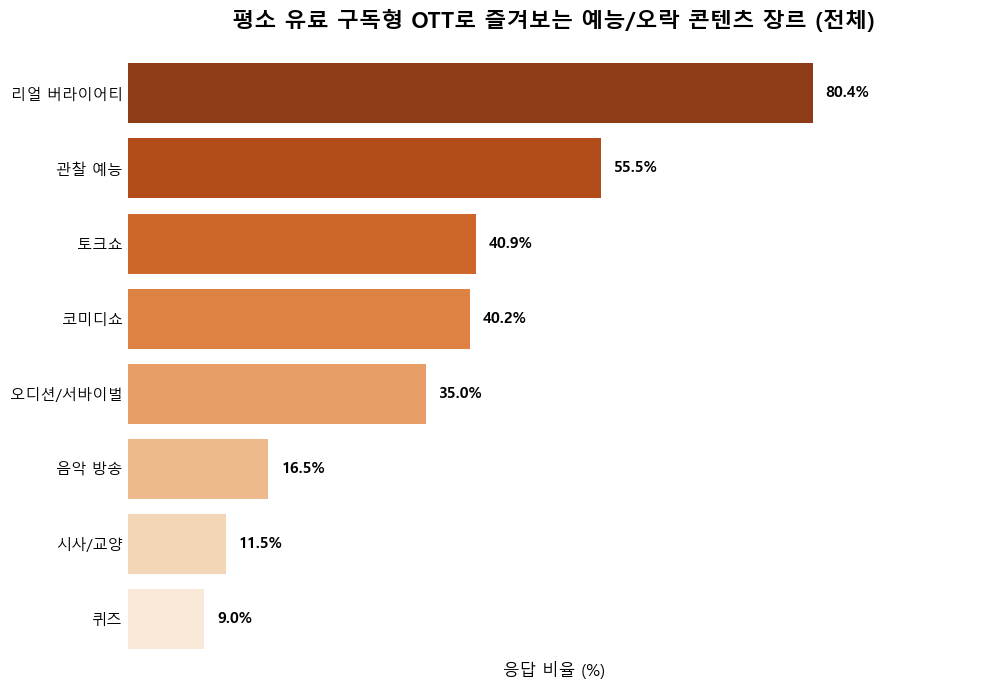

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '평소_유료_구독형_OTT로_즐겨보는_예능_오락_콘텐츠_장르_복수응답__20260409174738.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '전체' 데이터 추출 및 전처리
# '특성별(1)'이 '전체'인 행만 가져옵니다.
df_total = df[df['특성별(1)'] == '전체'].copy()

# 시각화에 불필요한 컬럼을 제외합니다.
df_genre = df_total.drop(columns=['특성별(1)', '특성별(2)', '사례수 (명)'], errors='ignore')

# 가로로 나열된 데이터를 세로(장르, 비율)로 변환 (Melt)
df_melted = df_genre.melt(var_name='장르', value_name='비율(%)')

# Y축 라벨이 깔끔하게 보이도록 문자열 끝의 ' (%)' 텍스트 제거
df_melted['장르'] = df_melted['장르'].str.replace(r' \(\%\)', '', regex=True).str.replace(' (%)', '', regex=False)

# 응답 비율이 높은 순서대로 내림차순 정렬
df_melted = df_melted.sort_values(by='비율(%)', ascending=False)

# 4. 그래프 그리기 설정
# 항목 텍스트 길이를 고려하여 세로 길이를 넉넉히 설정합니다.
plt.figure(figsize=(10, 7))

# 가로 막대 그래프 생성 (주황색 테마 적용)
ax = sns.barplot(data=df_melted, x='비율(%)', y='장르', hue='장르', palette='Oranges_r', legend=False)

# 5. 그래프 디자인 및 꾸미기
# X축 범위를 0~100으로 설정 (복수응답이므로 개별 비율의 최대치는 100%)
ax.set_xlim(0, 100)

# 막대 끝에 수치(텍스트) 표기
for p in ax.patches:
    width = p.get_width()
    if pd.notnull(width) and width > 0:
        # 막대 오른쪽 끝에서 약간(1.5) 떨어진 곳에 텍스트 표시
        ax.text(width + 1.5, 
                p.get_y() + p.get_height() / 2, 
                f'{width:.1f}%', 
                ha='left', 
                va='center', 
                fontsize=11, 
                fontweight='bold')

# 축 및 테두리 정리
plt.title('평소 유료 구독형 OTT로 즐겨보는 예능/오락 콘텐츠 장르 (전체)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('응답 비율 (%)', fontsize=12)
plt.ylabel('') # Y축 제목은 항목 자체가 설명하므로 생략

# 위, 오른쪽, 아래 테두리 및 X축 눈금 제거하여 깔끔하게 표시
sns.despine(left=True, bottom=True)
ax.set_xticks([]) 
ax.tick_params(axis='y', length=0, labelsize=11)

plt.tight_layout()
plt.show()

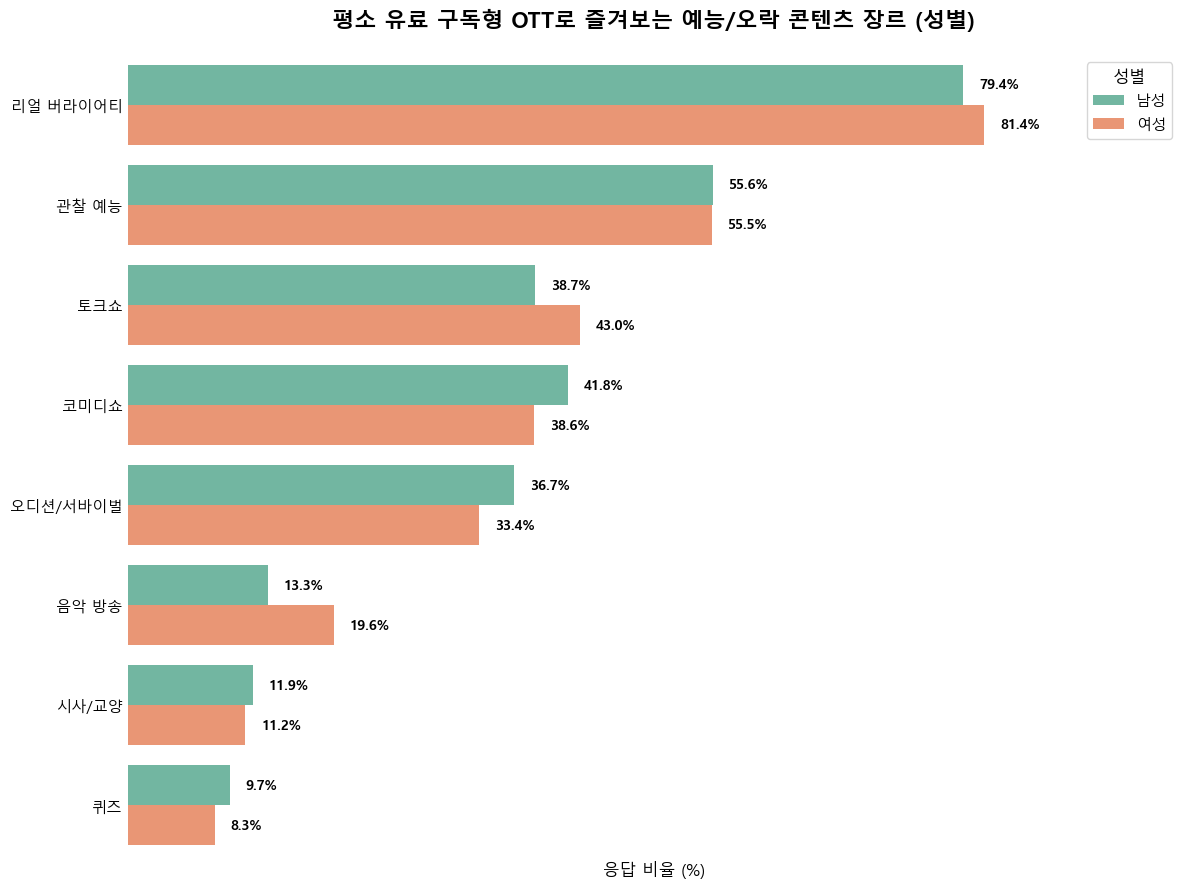

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '평소_유료_구독형_OTT로_즐겨보는_예능_오락_콘텐츠_장르_복수응답__20260409174738.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '성별' 데이터 추출 및 전처리
# '특성별(1)'이 '성별'인 행만 가져옵니다.
df_gender = df[df['특성별(1)'] == '성별'].copy()

# 시각화에 불필요한 컬럼을 제외합니다. ('특성별(2)'는 성별 구분을 위해 남겨둡니다)
df_genre = df_gender.drop(columns=['특성별(1)', '사례수 (명)'], errors='ignore')

# 가로로 나열된 데이터를 세로(장르, 비율)로 변환 (Melt)
# '특성별(2)'(성별)를 기준으로 데이터를 변환합니다.
df_melted = df_genre.melt(id_vars='특성별(2)', var_name='장르', value_name='비율(%)')

# 컬럼명 변경
df_melted.rename(columns={'특성별(2)': '성별'}, inplace=True)

# Y축 라벨이 깔끔하게 보이도록 문자열 끝의 ' (%)' 텍스트 제거
df_melted['장르'] = df_melted['장르'].str.replace(r' \(\%\)', '', regex=True).str.replace(' (%)', '', regex=False)

# 4. 그래프 그리기 설정
# 항목 텍스트가 길고 남녀 두 개의 막대가 들어가므로 세로 길이를 충분히 줍니다.
plt.figure(figsize=(12, 9))

# 가로 막대 그래프 생성 (성별 비교를 위해 hue 추가, 성별 구분이 쉬운 'Set2' 테마 적용)
ax = sns.barplot(data=df_melted, x='비율(%)', y='장르', hue='성별', palette='Set2')

# 5. 그래프 디자인 및 꾸미기
# X축 범위를 0~100으로 설정 (복수응답이므로 개별 비율의 최대치는 100%)
ax.set_xlim(0, 100)

# 막대 끝에 수치(텍스트) 표기
for p in ax.patches:
    width = p.get_width()
    if pd.notnull(width) and width > 0:
        # 막대 오른쪽 끝에서 약간(1.5) 떨어진 곳에 텍스트 표시
        ax.text(width + 1.5, 
                p.get_y() + p.get_height() / 2, 
                f'{width:.1f}%', 
                ha='left', 
                va='center', 
                fontsize=10, 
                fontweight='bold')

# 축 및 테두리 정리
plt.title('평소 유료 구독형 OTT로 즐겨보는 예능/오락 콘텐츠 장르 (성별)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('응답 비율 (%)', fontsize=12)
plt.ylabel('') # Y축 제목은 항목 자체가 설명하므로 생략

# 범례 위치 조정
plt.legend(title='성별', title_fontsize=12, fontsize=11, loc='upper right')

# 위, 오른쪽, 아래 테두리 및 X축 눈금 제거하여 깔끔하게 표시
sns.despine(left=True, bottom=True)
ax.set_xticks([]) 
ax.tick_params(axis='y', length=0, labelsize=11)

plt.tight_layout()
plt.show()

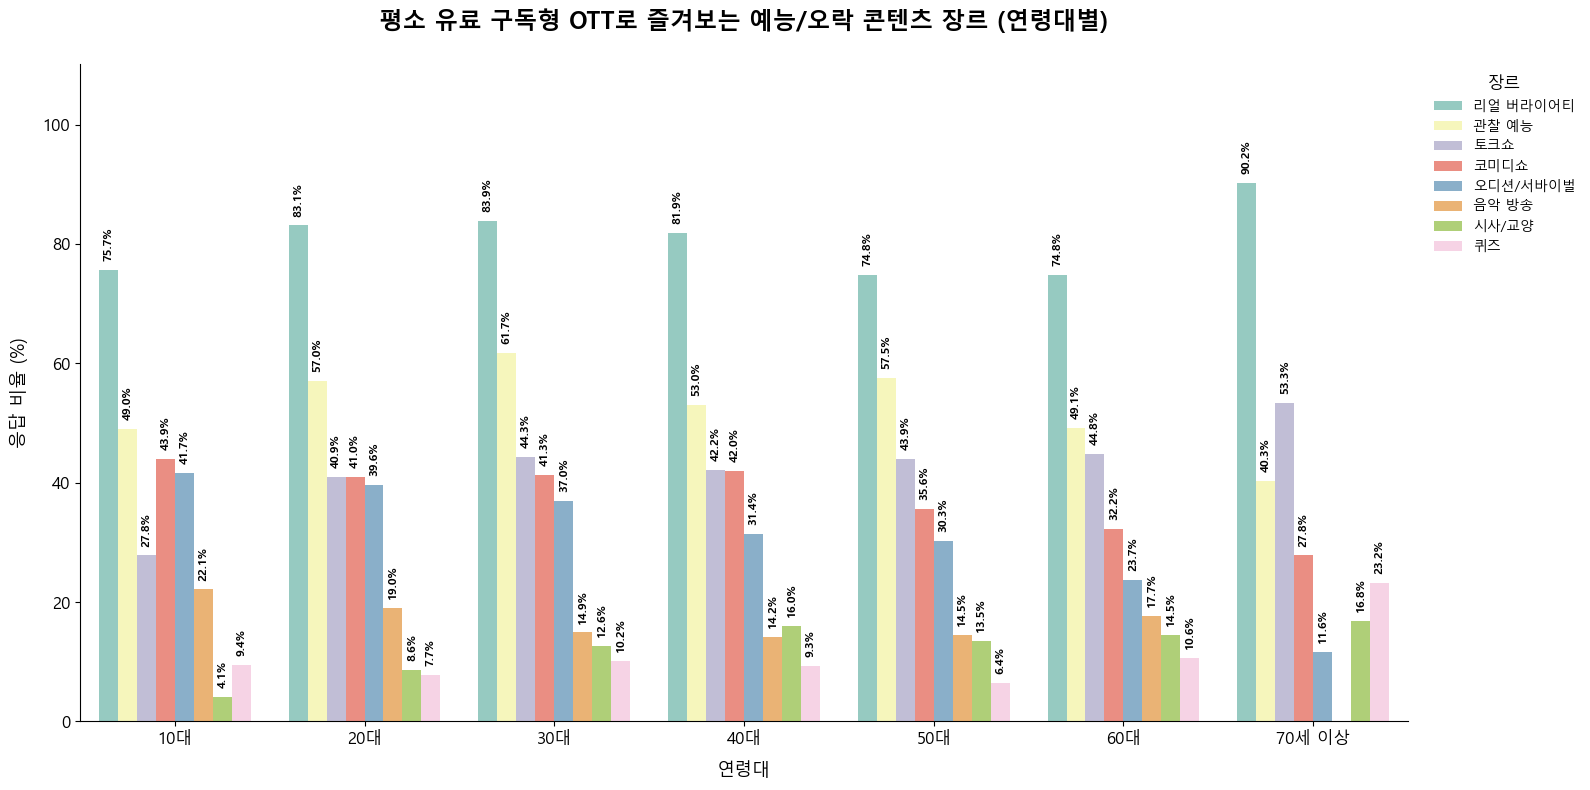

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '평소_유료_구독형_OTT로_즐겨보는_예능_오락_콘텐츠_장르_복수응답__20260409174738.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '연령' 데이터 추출 및 전처리
# '특성별(1)'이 '연령'인 행만 가져옵니다.
df_age = df[df['특성별(1)'] == '연령'].copy()

# 시각화에 불필요한 컬럼을 제외합니다.
df_genre = df_age.drop(columns=['특성별(1)', '사례수 (명)'], errors='ignore')

# 가로로 나열된 데이터를 세로(장르, 비율)로 변환 (Melt)
# '특성별(2)'(연령대)를 기준으로 데이터를 변환합니다.
df_melted = df_genre.melt(id_vars='특성별(2)', var_name='장르', value_name='비율(%)')

# 컬럼명 변경
df_melted.rename(columns={'특성별(2)': '연령대'}, inplace=True)

# Y축 라벨이 깔끔하게 보이도록 문자열 끝의 ' (%)' 텍스트 제거
df_melted['장르'] = df_melted['장르'].str.replace(r' \(\%\)', '', regex=True).str.replace(' (%)', '', regex=False)

# 4. 그래프 그리기 설정
# 항목이 많으므로 그래프 크기를 가로로 아주 넓게 설정합니다.
plt.figure(figsize=(16, 8))

# 세로 막대 그래프 생성 (X축: 연령대, 색상 구분: 장르, 구분이 잘 되는 Set3 테마 적용)
ax = sns.barplot(data=df_melted, x='연령대', y='비율(%)', hue='장르', palette='Set3')

# 5. 그래프 디자인 및 꾸미기
# 텍스트와 범례 공간 확보를 위해 Y축 범위를 넉넉하게 설정
max_val = df_melted['비율(%)'].max()
ax.set_ylim(0, max_val + 20)

# 막대 위에 수치(텍스트) 표기
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        # 막대가 좁으므로 텍스트가 겹치지 않게 세로(90도)로 회전시킵니다.
        ax.text(p.get_x() + p.get_width() / 2., 
                height + 1.5, 
                f'{height:.1f}%', 
                ha='center', 
                va='bottom', 
                fontsize=8.5, 
                fontweight='bold',
                rotation=90)

# 축 및 테두리 정리
plt.title('평소 유료 구독형 OTT로 즐겨보는 예능/오락 콘텐츠 장르 (연령대별)', fontsize=17, pad=25, fontweight='bold')
plt.xlabel('연령대', fontsize=13, labelpad=10)
plt.ylabel('응답 비율 (%)', fontsize=13, labelpad=10)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 범례 위치 조정 (그래프 우측 바깥으로 분리)
plt.legend(title='장르', title_fontsize=12, fontsize=10, loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False)

# 위, 오른쪽 테두리 제거하여 깔끔하게 표시
sns.despine()

plt.tight_layout()
plt.show()

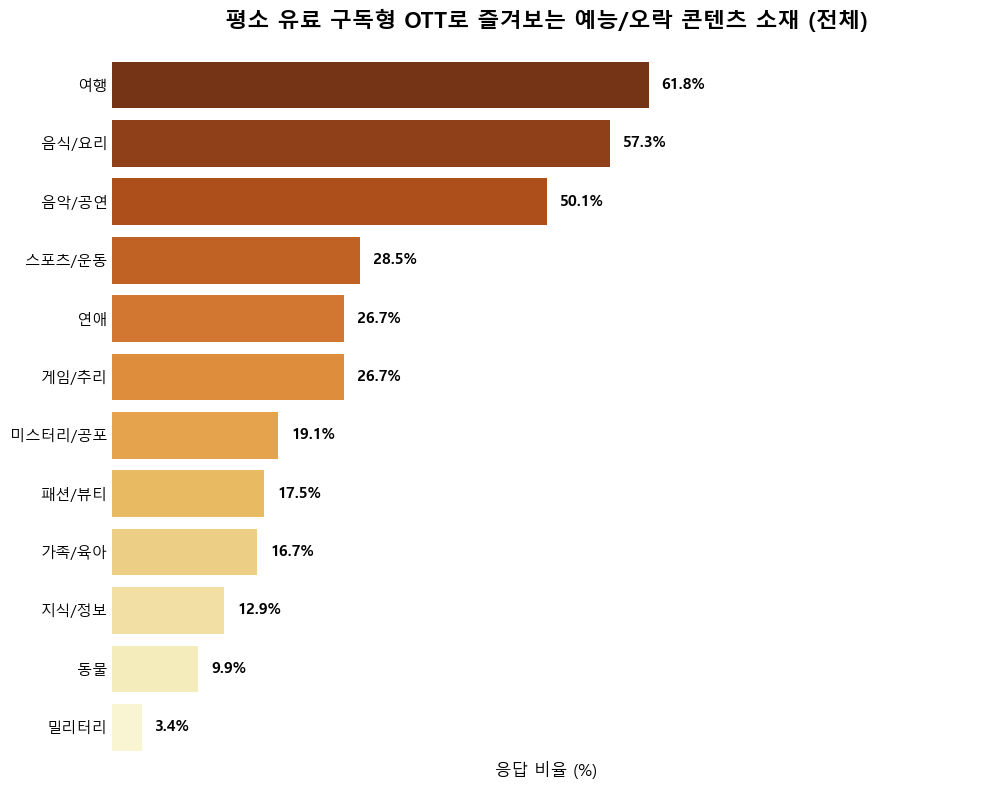

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '평소_유료_구독형_OTT로_즐겨보는_예능_오락_콘텐츠_소재_복수응답__20260409181011.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '전체' 데이터 추출 및 전처리
# '특성별(1)'이 '전체'인 행만 가져옵니다.
df_total = df[df['특성별(1)'] == '전체'].copy()

# 시각화에 불필요한 컬럼을 제외합니다.
df_subject = df_total.drop(columns=['특성별(1)', '특성별(2)', '사례수 (명)'], errors='ignore')

# 가로로 나열된 데이터를 세로(소재, 비율)로 변환 (Melt)
df_melted = df_subject.melt(var_name='소재', value_name='비율(%)')

# Y축 라벨이 깔끔하게 보이도록 문자열 끝의 ' (%)' 텍스트 제거
df_melted['소재'] = df_melted['소재'].str.replace(r' \(\%\)', '', regex=True).str.replace(' (%)', '', regex=False)

# 응답 비율이 높은 순서대로 내림차순 정렬
df_melted = df_melted.sort_values(by='비율(%)', ascending=False)

# 4. 그래프 그리기 설정
# 항목 텍스트가 길고 많으므로 세로 길이를 넉넉하게 줍니다.
plt.figure(figsize=(10, 8))

# 가로 막대 그래프 생성 (예능의 밝은 느낌을 주는 옐로우-오렌지 톤의 'YlOrBr_r' 테마 적용)
ax = sns.barplot(data=df_melted, x='비율(%)', y='소재', hue='소재', palette='YlOrBr_r', legend=False)

# 5. 그래프 디자인 및 꾸미기
# X축 범위를 0~100으로 설정 (복수응답이므로 개별 비율의 최대치는 100%)
ax.set_xlim(0, 100)

# 막대 끝에 수치(텍스트) 표기
for p in ax.patches:
    width = p.get_width()
    if pd.notnull(width) and width > 0:
        # 막대 오른쪽 끝에서 약간(1.5) 떨어진 곳에 텍스트 표시
        ax.text(width + 1.5, 
                p.get_y() + p.get_height() / 2, 
                f'{width:.1f}%', 
                ha='left', 
                va='center', 
                fontsize=11, 
                fontweight='bold')

# 축 및 테두리 정리
plt.title('평소 유료 구독형 OTT로 즐겨보는 예능/오락 콘텐츠 소재 (전체)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('응답 비율 (%)', fontsize=12)
plt.ylabel('') # Y축 제목은 항목 자체가 설명하므로 생략

# 위, 오른쪽, 아래 테두리 및 X축 눈금 제거하여 깔끔하게 표시
sns.despine(left=True, bottom=True)
ax.set_xticks([]) 
ax.tick_params(axis='y', length=0, labelsize=11)

plt.tight_layout()
plt.show()

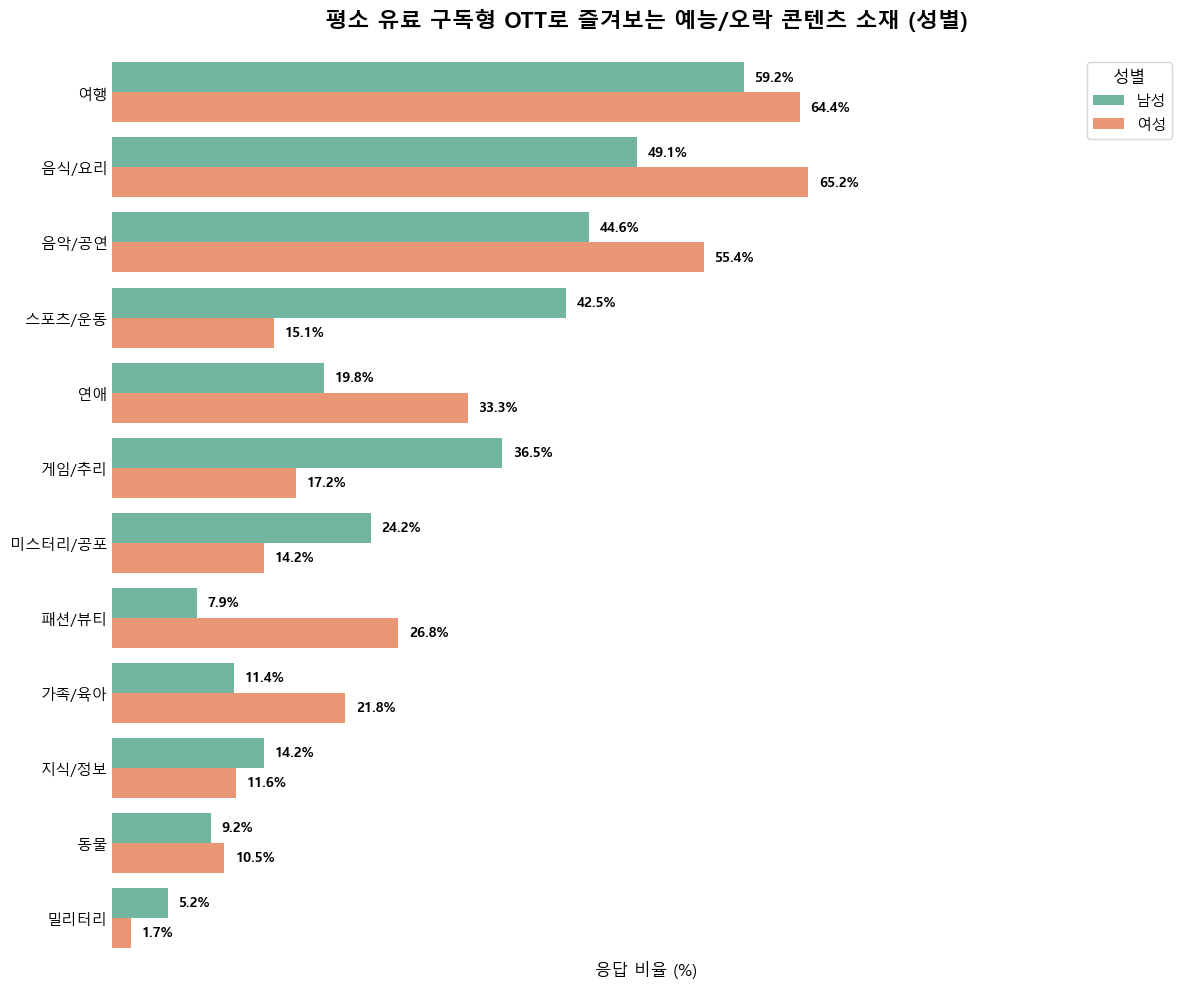

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '평소_유료_구독형_OTT로_즐겨보는_예능_오락_콘텐츠_소재_복수응답__20260409181011.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '성별' 데이터 추출 및 전처리
# '특성별(1)'이 '성별'인 행만 가져옵니다.
df_gender = df[df['특성별(1)'] == '성별'].copy()

# 시각화에 불필요한 컬럼을 제외합니다. ('특성별(2)'는 성별 구분을 위해 남겨둡니다)
df_subject = df_gender.drop(columns=['특성별(1)', '사례수 (명)'], errors='ignore')

# 가로로 나열된 데이터를 세로(소재, 비율)로 변환 (Melt)
# '특성별(2)'(성별)를 기준으로 데이터를 변환합니다.
df_melted = df_subject.melt(id_vars='특성별(2)', var_name='소재', value_name='비율(%)')

# 컬럼명 변경
df_melted.rename(columns={'특성별(2)': '성별'}, inplace=True)

# Y축 라벨이 깔끔하게 보이도록 문자열 끝의 ' (%)' 텍스트 제거
df_melted['소재'] = df_melted['소재'].str.replace(r' \(\%\)', '', regex=True).str.replace(' (%)', '', regex=False)

# 4. 그래프 그리기 설정
# 항목 텍스트가 길고 남녀 두 개의 막대가 들어가므로 세로 길이를 충분히 줍니다.
plt.figure(figsize=(12, 10))

# 가로 막대 그래프 생성 (성별 비교를 위해 hue 추가, 성별 구분이 쉬운 'Set2' 테마 적용)
ax = sns.barplot(data=df_melted, x='비율(%)', y='소재', hue='성별', palette='Set2')

# 5. 그래프 디자인 및 꾸미기
# X축 범위를 0~100으로 설정 (복수응답이므로 개별 비율의 최대치는 100%)
ax.set_xlim(0, 100)

# 막대 끝에 수치(텍스트) 표기
for p in ax.patches:
    width = p.get_width()
    if pd.notnull(width) and width > 0:
        # 막대 오른쪽 끝에서 약간(1.0) 떨어진 곳에 텍스트 표시
        ax.text(width + 1.0, 
                p.get_y() + p.get_height() / 2, 
                f'{width:.1f}%', 
                ha='left', 
                va='center', 
                fontsize=10, 
                fontweight='bold')

# 축 및 테두리 정리
plt.title('평소 유료 구독형 OTT로 즐겨보는 예능/오락 콘텐츠 소재 (성별)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('응답 비율 (%)', fontsize=12)
plt.ylabel('') # Y축 제목은 항목 자체가 설명하므로 생략

# 범례 위치 조정
plt.legend(title='성별', title_fontsize=12, fontsize=11, loc='upper right')

# 위, 오른쪽, 아래 테두리 및 X축 눈금 제거하여 깔끔하게 표시
sns.despine(left=True, bottom=True)
ax.set_xticks([]) 
ax.tick_params(axis='y', length=0, labelsize=11)

plt.tight_layout()
plt.show()

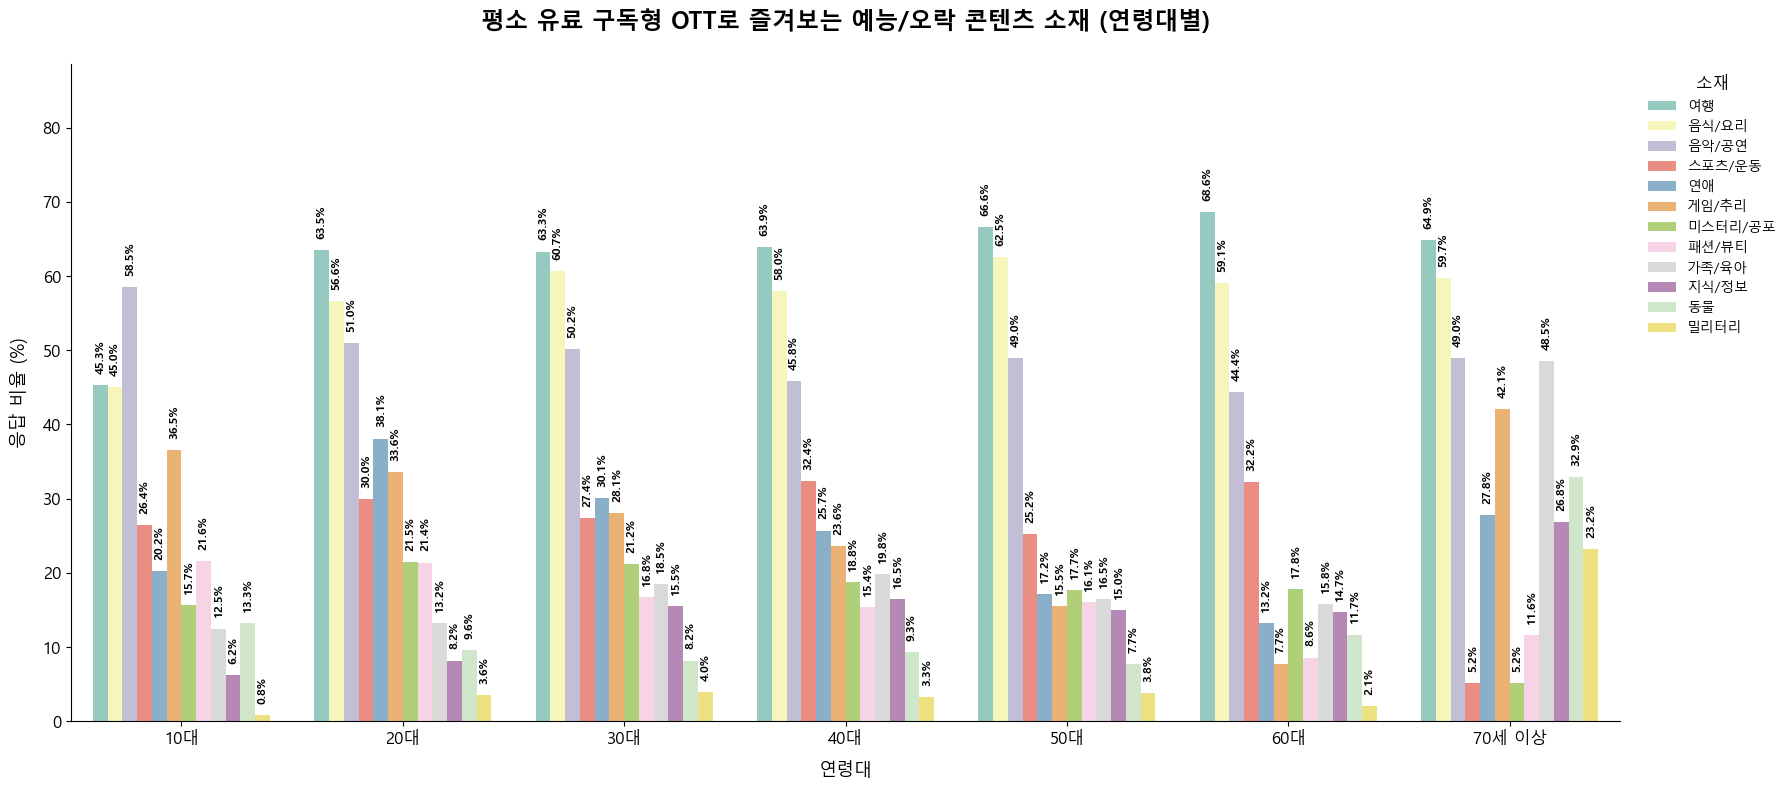

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '평소_유료_구독형_OTT로_즐겨보는_예능_오락_콘텐츠_소재_복수응답__20260409181011.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '연령' 데이터 추출 및 전처리
# '특성별(1)'이 '연령'인 행만 가져옵니다.
df_age = df[df['특성별(1)'] == '연령'].copy()

# 시각화에 불필요한 컬럼을 제외합니다. ('특성별(2)'는 연령대 구분을 위해 남겨둡니다)
df_subject = df_age.drop(columns=['특성별(1)', '사례수 (명)'], errors='ignore')

# 가로로 나열된 데이터를 세로(소재, 비율)로 변환 (Melt)
# '특성별(2)'(연령대)를 기준으로 데이터를 변환합니다.
df_melted = df_subject.melt(id_vars='특성별(2)', var_name='소재', value_name='비율(%)')

# 컬럼명 변경
df_melted.rename(columns={'특성별(2)': '연령대'}, inplace=True)

# Y축 라벨이 깔끔하게 보이도록 문자열 끝의 ' (%)' 텍스트 제거
df_melted['소재'] = df_melted['소재'].str.replace(r' \(\%\)', '', regex=True).str.replace(' (%)', '', regex=False)

# 4. 그래프 그리기 설정
# 항목이 많으므로 그래프 크기를 가로로 아주 넓게 설정합니다.
plt.figure(figsize=(18, 8))

# 세로 막대 그래프 생성 (X축: 연령대, 색상 구분: 소재, 구분이 잘 되는 Set3 테마 적용)
ax = sns.barplot(data=df_melted, x='연령대', y='비율(%)', hue='소재', palette='Set3')

# 5. 그래프 디자인 및 꾸미기
# 텍스트와 범례 공간 확보를 위해 Y축 범위를 더 넉넉하게 설정
max_val = df_melted['비율(%)'].max()
ax.set_ylim(0, max_val + 20)

# 막대 위에 수치(텍스트) 표기
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        # 막대가 좁으므로 텍스트가 겹치지 않게 세로(90도)로 회전시킵니다.
        ax.text(p.get_x() + p.get_width() / 2., 
                height + 1.5, 
                f'{height:.1f}%', 
                ha='center', 
                va='bottom', 
                fontsize=8.5, 
                fontweight='bold',
                rotation=90)

# 축 및 테두리 정리
plt.title('평소 유료 구독형 OTT로 즐겨보는 예능/오락 콘텐츠 소재 (연령대별)', fontsize=17, pad=25, fontweight='bold')
plt.xlabel('연령대', fontsize=13, labelpad=10)
plt.ylabel('응답 비율 (%)', fontsize=13, labelpad=10)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 범례 위치 조정 (그래프 우측 바깥으로 분리)
plt.legend(title='소재', title_fontsize=12, fontsize=10, loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False)

# 위, 오른쪽 테두리 제거하여 깔끔하게 표시
sns.despine()

plt.tight_layout()
plt.show()